# End 2 End notebook for fingerprint classification project
This notebook eseentially does : 
1. Explore dataset contains from existing directories
2. Creates Train / Validation / Test datasets 
3. Create classification model with a pre-trained MobileNet version with the following architecture
   MobileNet -> Hidden Dense Layers -> Classification Layer
4. Carries out Transfer Learning with frozen pre-trained MobileNet based model
5. Carries out Fine-Tuning with unfrozen last n-th layers of the pre-trained MobileNet base model 
6. Evaluation and comparison of both transfer learning and fine tuning models

## Project Pre-requisites

In [1]:
# Import libraries
import os
from pathlib import Path
import random
import itertools

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import confusion_matrix, classification_report

## Projet Hyper-parameters
Principal knobs to parametrize this projet 

1. Datasets parameters
   1. Number of classes i.e. fingers to consider for the classification problem
   2. split ratio for validation and test datasets, paer default set to 2/3 validation vs. 1/3 test
2. Model Architecture parameters
   1. MobileNet version
   2. Number of neurons in first hidden dense layer, the second dense layer uses this number divived by 4
      (other architectures with a single dense layer and 3 distinct dense layers have been explored but number of dense layers is not parametrizable)
   3. activation function of hidden dense layers is set to leak_relu with slope = 0.001
      (other activation functions relu, gelu, gelu_approx, leaky_rely with slope = 0.2 have been explore)
   4. Dropout rate of layers associated with hidden dense layers in set to 0.3 
      (no exaploration has been carried out with lower values, to avoid overfitting)
3. Training paramters
   1. Number of epochs, patience for both transfer learning and fine tuning

In [2]:
# pre-trained model selection
MobileNet_version = "MobileNetV2"

if MobileNet_version == "MobileNet":
    from tensorflow.keras.applications import MobileNet
    from tensorflow.keras.applications.mobilenet import preprocess_input
elif MobileNet_version == "MobileNetV2":
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
elif MobileNet_version == "MobileNetV3Small":
    from tensorflow.keras.applications import MobileNetV3Small
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
elif MobileNet_version == "MobileNetV3Large":
    from tensorflow.keras.applications import MobileNetV3Large
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
else:
    print("Unknown MobileNet version name")
    exit(0)

In [3]:
# Check selected pre-trained model
print(f"Selected pre-trained model version : {MobileNet_version}")

Selected pre-trained model version : MobileNetV2


In [4]:
# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le transfer learning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.16.2
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le transfer learning en computer vision !


## Project Constants

In [5]:
# Random seeding 
TENSORFLOW_RANDOM_SEED = 42
tf.random.set_seed(TENSORFLOW_RANDOM_SEED)

NUMPY_RANDOM_SEED = 42
np.random.seed(NUMPY_RANDOM_SEED)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Dataset selection
DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom" 
print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

# labels
# class_names = ['thumb', 'index', 'middle', 'ring', 'little']
class_names = ['thumb', 'index']

num_classes = len(class_names)
print(f"\n👁️ {num_classes} fingerprints classes : {class_names}")

# model name
fingerprint_model_base_name = MobileNet_version + "_FingerPrint_Model"
fingerprint_model_name = fingerprint_model_base_name + "_" + str(num_classes) + "_classes"
print(f"Fingerprint model name : {fingerprint_model_name}")

📁 Fingerprints dataset images root directory path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom

👁️ 2 fingerprints classes : ['thumb', 'index']
Fingerprint model name : MobileNetV2_FingerPrint_Model_2_classes


## 1. Dataset Exploration
The original dataset SOCOFing was found from kaggle @ https://www.kaggle.com/datasets/mreccentric/socofing-full-modified/data
It contains roughly 55k, greyscaled and (96, 103) images, of which 
- 6k original images
- 49k low-medium-high altered original images (cut, blur, drop), examples below

A subset of the above is been considered for training / validation / test as followx : 
- 6k original images, 1.2k images by class
- 18k low altered images : 6k zcut, 6k blur and 6k drop, 3.6k images by class
- Total of 24k images, 4.8 images by class

Considering that altered images are actually augmented for the training steps, this subset has then been manually split to
mimic the rain / validation / test separation as follow:

For each finger class (1.2K images), randomly split original images into two sets, i.e. train = 800 and validation/test = 400
For each of the images in the train set, collect the corresponding altered images, i.e. cut, blur and drop. 
Then split validation and test using VALIDATION_TEST_DATASET_RATIO, set to 2/3 vs. 1/3 in this notebook 

This creates the following dataset for each class : 
- train = 800 + 3 * 800 = 3200 images
- validation = 300 images
- test = 100 images

To sum up, the dataset contains 18k images, with 3.6k images by class 

In [6]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [7]:
# utility function to collect images and classes
def traverse_dataset_dir(dataset_dir, class_names):
    '''
        return a dataframe containing image files information and corresponding classes from the dataset directory
            dataset_dir : directory to scan
            class_names : labels to consider
    '''
    # List to store file information
    imgdata = []

    # Traverse the input directory to get all image files
    for dirname, _, filenames in os.walk(dataset_dir):

        # check whether image is in a class which ought to be considered
        try:
            basename = os.path.basename(dirname)
            val = class_names.index(basename)
        except ValueError:
            # class not found
            continue

        # Traverse the image files
        for filename in filenames:
         
            if filename == ".DS_Store":  # Skip macOS system files
                continue

            # identifies class 
            if filename.find("thumb") != -1:
                finger = "thumb"
            elif filename.find("index") != -1:
                finger = "index"
            elif filename.find("middle") != -1:
                finger = "middle"
            elif filename.find("ring") != -1:
                finger = "ring"
            elif filename.find("little") != -1:
                finger = "little"
            else:
                finger = None

            # identifies alteration type from filename
            if filename.find("Zcut") != -1:
                feature = 'zcut'
            elif filename.find('CR') != -1:
                feature = 'cr'
            elif filename.find('Obl') != -1:
                feature = 'obl'
            else:
                feature = 'unaltered'

            # image is to be considered given the current class names 
            file_path = os.path.join(dirname, filename)
    
            try:
                img = Image.open(file_path)
                img.verify()  # Verify that the file is a valid image
            except:
                print(f"Invalid image file: {file_path}")
                continue

            imgdata.append([file_path, img.format, img.size, img.mode, feature, finger])

    # Create a DataFrame
    imgdf = pd.DataFrame(imgdata, columns=["ImagePath", "ImageFormat", "ImageSize", "ImageMode", "Feature", "Finger"])

    # Add an index column
    imgdf.index.name = "ID"

    return imgdf

In [8]:
# explore train dataset
dataset_train_dir = DATASET_ROOTDIR_PATH + "/train"
imgdf = traverse_dataset_dir(dataset_train_dir, class_names)

In [9]:
# display the dataframe info
imgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 6382 entries, 0 to 6381
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImagePath    6382 non-null   str   
 1   ImageFormat  6382 non-null   str   
 2   ImageSize    6382 non-null   object
 3   ImageMode    6382 non-null   str   
 4   Feature      6382 non-null   str   
 5   Finger       6382 non-null   str   
dtypes: object(1), str(5)
memory usage: 299.3+ KB


In [10]:
# check null values
imgdf.isnull().sum()

ImagePath      0
ImageFormat    0
ImageSize      0
ImageMode      0
Feature        0
Finger         0
dtype: int64

In [11]:
# Display the distribution of Feature, Finger
print(imgdf["Feature"].value_counts())
print(imgdf["Finger"].value_counts())

Feature
unaltered    1600
obl          1598
zcut         1594
cr           1590
Name: count, dtype: int64
Finger
index    3192
thumb    3190
Name: count, dtype: int64


In [12]:
# Display of number of thumbs, index, middle, ring, and little fingers
print(f"Percentage of Thumbs: {imgdf['Finger'].value_counts().get('thumb', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Index fingers: {imgdf['Finger'].value_counts().get('index', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Middle fingers: {imgdf['Finger'].value_counts().get('middle', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Ring fingers: {imgdf['Finger'].value_counts().get('ring', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Little fingers: {imgdf['Finger'].value_counts().get('little', 0) / len(imgdf) * 100:.2f}%")

Percentage of Thumbs: 49.98%
Percentage of Index fingers: 50.02%
Percentage of Middle fingers: 0.00%
Percentage of Ring fingers: 0.00%
Percentage of Little fingers: 0.00%


In [13]:
# Display of number of features
print(f"Percentage of unaltered: {imgdf['Feature'].value_counts().get('unaltered', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Zcut: {imgdf['Feature'].value_counts().get('zcut', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of CR: {imgdf['Feature'].value_counts().get('cr', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Obl: {imgdf['Feature'].value_counts().get('obl', 0) / len(imgdf) * 100:.2f}%")

Percentage of unaltered: 25.07%
Percentage of Zcut: 24.98%
Percentage of CR: 24.91%
Percentage of Obl: 25.04%


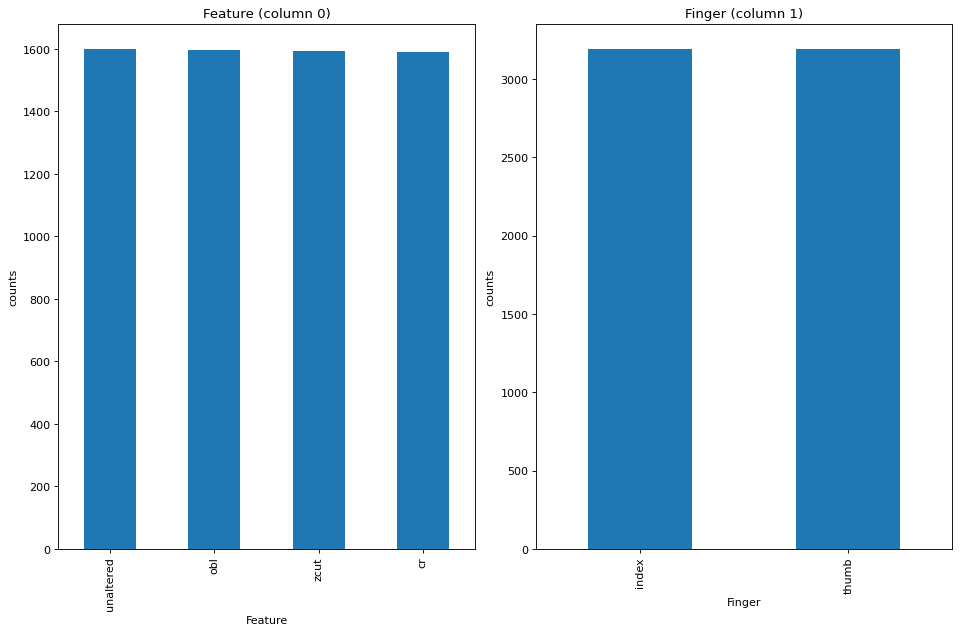

In [14]:
plotPerColumnDistribution(imgdf, 10, 5)

FingerPrint Examples from dataset dir /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom/train/



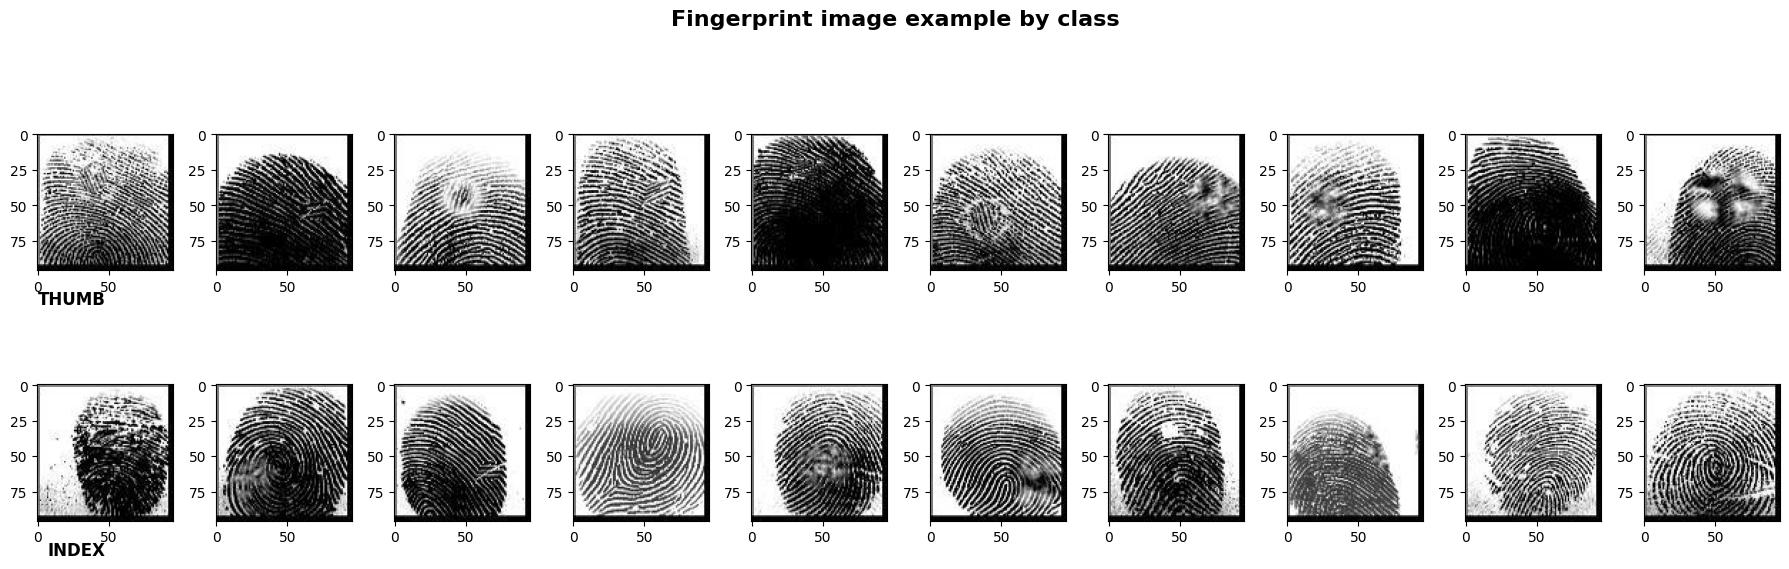

In [15]:
# visualisation of some images
dataset_target_dir = DATASET_ROOTDIR_PATH + "/train/"
print(f"FingerPrint Examples from dataset dir {dataset_target_dir}\n")

num_examples_images = 10
fig, axes = plt.subplots(num_classes, num_examples_images, figsize=(18, 3 * num_classes))

for i, class_name in enumerate(class_names):
    class_path = Path(os.path.join(dataset_target_dir, class_name))
    image_files = list(class_path.glob('*.*'))[:num_examples_images]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('on')
        if j == 0:
            axes[i, j].set_xlabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.suptitle("Fingerprint image example by class", fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

In [16]:
# validation/test dataset
dataset_val_dir = DATASET_ROOTDIR_PATH + "/validation"
imgdf = traverse_dataset_dir(dataset_val_dir, class_names)

In [17]:
# display the dataframe info
imgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImagePath    800 non-null    str   
 1   ImageFormat  800 non-null    str   
 2   ImageSize    800 non-null    object
 3   ImageMode    800 non-null    str   
 4   Feature      800 non-null    str   
 5   Finger       800 non-null    str   
dtypes: object(1), str(5)
memory usage: 37.6+ KB


In [18]:
# check null values
imgdf.isnull().sum()

ImagePath      0
ImageFormat    0
ImageSize      0
ImageMode      0
Feature        0
Finger         0
dtype: int64

In [19]:
# Display the distribution of Feature, Finger
print(imgdf["Feature"].value_counts())
print(imgdf["Finger"].value_counts())

Feature
unaltered    800
Name: count, dtype: int64
Finger
thumb    400
index    400
Name: count, dtype: int64


In [20]:
# Display of number of thumbs, index, middle, ring, and little fingers
print(f"Percentage of Thumbs: {imgdf['Finger'].value_counts().get('thumb', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Index fingers: {imgdf['Finger'].value_counts().get('index', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Middle fingers: {imgdf['Finger'].value_counts().get('middle', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Ring fingers: {imgdf['Finger'].value_counts().get('ring', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Little fingers: {imgdf['Finger'].value_counts().get('little', 0) / len(imgdf) * 100:.2f}%")

Percentage of Thumbs: 50.00%
Percentage of Index fingers: 50.00%
Percentage of Middle fingers: 0.00%
Percentage of Ring fingers: 0.00%
Percentage of Little fingers: 0.00%


In [21]:
# Display of feature
print(f"Percentage of unaltered: {imgdf['Feature'].value_counts().get('unaltered', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Zcut: {imgdf['Feature'].value_counts().get('zcut', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of CR: {imgdf['Feature'].value_counts().get('cr', 0) / len(imgdf) * 100:.2f}%")
print(f"Percentage of Obl: {imgdf['Feature'].value_counts().get('obl', 0) / len(imgdf) * 100:.2f}%")

Percentage of unaltered: 100.00%
Percentage of Zcut: 0.00%
Percentage of CR: 0.00%
Percentage of Obl: 0.00%


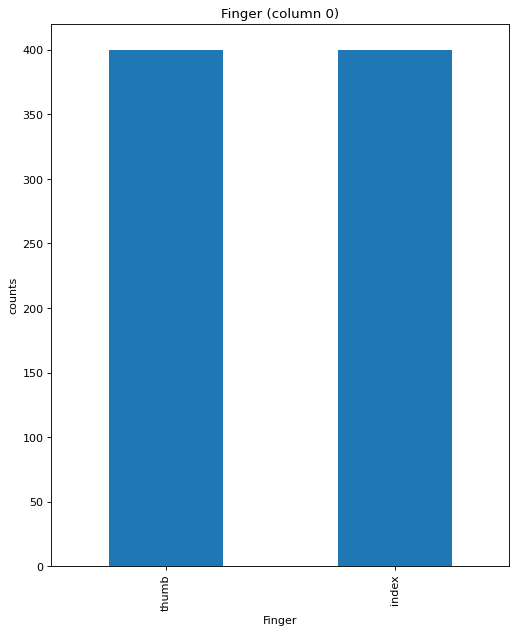

In [22]:
plotPerColumnDistribution(imgdf, 10, 5)

FingerPrint Examples from dataset dir /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom/validation/



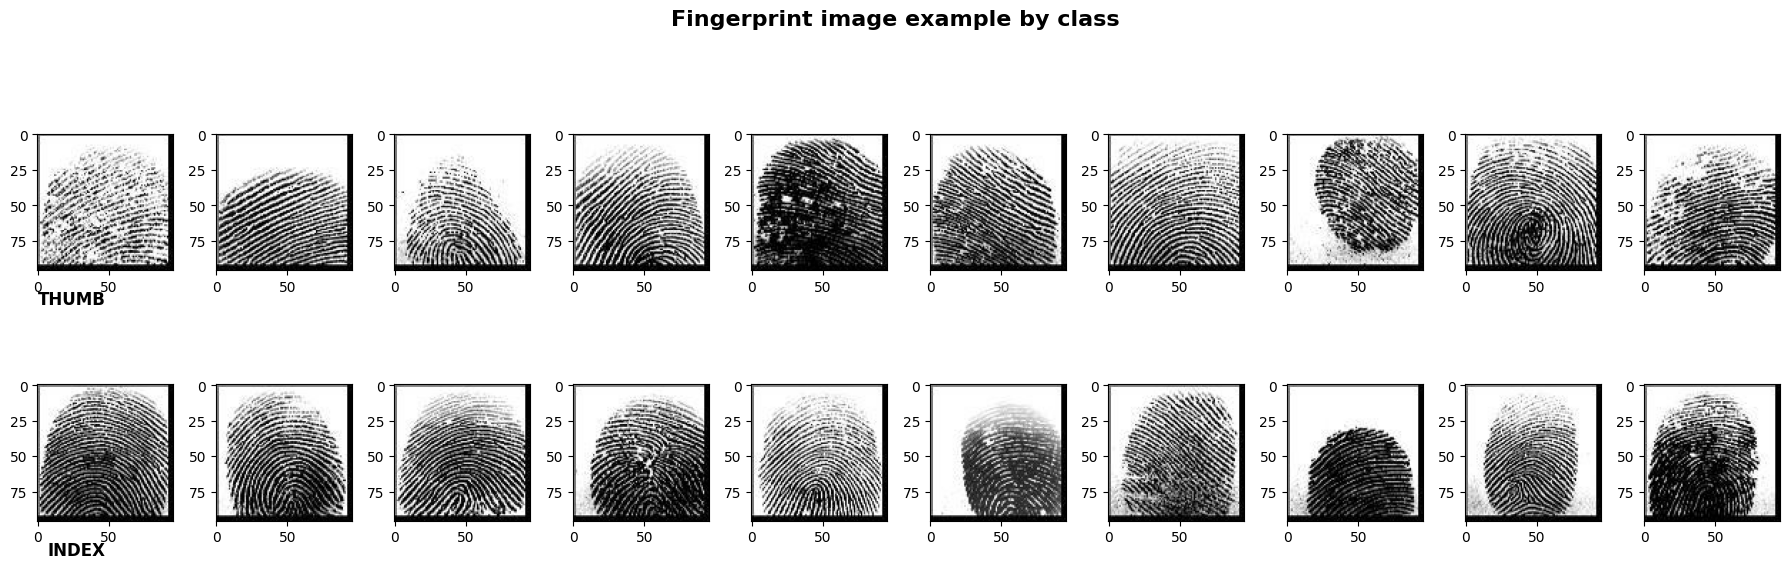

In [23]:
# visualisation of some images
dataset_target_dir = DATASET_ROOTDIR_PATH + "/validation/"
print(f"FingerPrint Examples from dataset dir {dataset_target_dir}\n")

num_examples_images = 10
fig, axes = plt.subplots(num_classes, num_examples_images, figsize=(18, 3 * num_classes))

for i, class_name in enumerate(class_names):
    class_path = Path(os.path.join(dataset_target_dir, class_name))
    image_files = list(class_path.glob('*.*'))[:num_examples_images]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('on')
        if j == 0:
            axes[i, j].set_xlabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.suptitle("Fingerprint image example by class", fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

## 2. Create datasets for training / validation / test

In [24]:
print("🔧 Datasets creation for training and validation/test ...\n")

# Dataset creation parameters
BATCH_SIZE = 64
IMAGE_SIZE = (96, 96)

# Create traning dataset with class filtering
dataset_train_dir = DATASET_ROOTDIR_PATH + "/train"
train_ds = image_dataset_from_directory(
    dataset_train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # One-hot encoding for multi-class
    class_names=class_names  # Explicitly specify the class names to ensure correct mapping
)

# Create validation dataset with the same class names to ensure correct mapping
dataset_val_dir = DATASET_ROOTDIR_PATH + "/validation"
val_test_ds = image_dataset_from_directory(
    dataset_val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Same order of classes
)

# split validation dataset into 2 using 2/3 validation and 1/3 test ratio
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds_cardinality = int(val_batches * 33 / 100)

test_ds = val_test_ds.take(test_ds_cardinality)
test_ds.class_names = class_names
val_ds = val_test_ds.skip(test_ds_cardinality)
val_ds.class_names = class_names

print(f"✅ Datasets created !\n")

print(f"📊 Training, validation and datasets information:")
print(f"  - Training Dataset Classes        : {train_ds.class_names}")
print(f"  - Validation Dataset Classes      : {val_ds.class_names}")
print(f"  - Test Dataset Classes            : {test_ds.class_names}")

# Checking number of classes in both datasets
if len(train_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(train_ds.class_names)} classes found instead of {num_classes} in training dataset !")
    print(f"   Classes found: {train_ds.class_names}\n")
elif len(val_test_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(val_test_ds.class_names)} classes found instead of {num_classes} in validation dataset !")
    print(f"   Classes found : {val_test_ds.class_names}")
else:
    print(f"  - ✅ Number of correct classes : {num_classes} \n")

print(f"  - Training batches    : {len(train_ds)}")
print(f"  - Validation batches  : {len(val_ds)}")
print(f"  - Test batches        : {len(test_ds)}")
print(f"  - Batch size          : {BATCH_SIZE}")
print(f"  - Training samples    : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Validation samples  : ~{len(val_ds) * BATCH_SIZE}")
print(f"  - Test samples        : ~{len(test_ds) * BATCH_SIZE}")

🔧 Datasets creation for training and validation/test ...

Found 6382 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
✅ Datasets created !

📊 Training, validation and datasets information:
  - Training Dataset Classes        : ['thumb', 'index']
  - Validation Dataset Classes      : ['thumb', 'index']
  - Test Dataset Classes            : ['thumb', 'index']
  - ✅ Number of correct classes : 2 

  - Training batches    : 100
  - Validation batches  : 9
  - Test batches        : 4
  - Batch size          : 64
  - Training samples    : ~6400
  - Validation samples  : ~576
  - Test samples        : ~256


2026-03-27 15:57:12.611802: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-27 15:57:12.611829: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-27 15:57:12.611838: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-27 15:57:12.611856: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-27 15:57:12.611868: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# 3. Train / validation / test datasets preparation for training
    This consists in normalisation and shuffling (training only)
    (no augmentation of train dataset is carried out since altered images are already embeded in it)

In [25]:
print("🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...\n")

# Dataset preparation function
def prepare_dataset(ds, shuffle=True):

    # normalisation is required for MobileNet
    # this is carried out with keras.utils.preprocess_input
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle (training only)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    
    # Performances optimisation
    ds = ds.cache()  # Memory caching
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch for acceleration
    
    return ds

# Apply transformations
train_ds_prepared = prepare_dataset(train_ds, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, shuffle=False)
test_ds_prepared = prepare_dataset(test_ds, shuffle=False)

print("✅ Dataset preparation completed !\n")

print("📝 Applied transformations :")
print("  - Training dataset   : normalisation + shuffle")
print("  - Validation dataset : Normalisation")
print("  - Test dataset       : Normalisation")

print("\n  - Caching et prefetch activated for performance")

🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...

✅ Dataset preparation completed !

📝 Applied transformations :
  - Training dataset   : normalisation + shuffle
  - Validation dataset : Normalisation
  - Test dataset       : Normalisation

  - Caching et prefetch activated for performance


## 4. Build FingerPrint Model
Pre-trained MobileNet-based model + Hidden dense layers + Classifier layer

In [26]:
# Constants for the model
INPUT_SHAPE = (96, 96, 3)
NUM_CLASSES = num_classes

# Size of intermediate dense layers between base-model and classifier stage
HIDDEN_DENSE_LAYERS_SIZE = [256, 64]

# activation function
def leaky_relu(x):
    return keras.activations.relu(x, negative_slope=0.01)

ACTIVATION_FUNCTION = leaky_relu

# Regularization setting
L2_REGULARIZATION = 0.01
DROPOUT_RATE = 0.3

# Learning Rate Standard for Transfer Learning of frozen model 
LEARNING_RATE = 0.001

In [27]:
print(f"📥 Loading {MobileNet_version} ...")

MobileNet_basename = MobileNet_version + "_FingerPrint_BaseModel"

# Loading pre-trained MobileNet without the classifier (include_top=False)
if MobileNet_version == "MobileNet":
    base_model = MobileNet(
        name=MobileNet_basename,
        input_shape=INPUT_SHAPE,
        include_top=False,  # Exclure la couche de classification ImageNet
        weights='imagenet',  # Load pre-trained weights from ImageNet
        pooling='avg'  # Global Average Pooling to end model
    )
elif MobileNet_version == "MobileNetV2":
    base_model = MobileNetV2(
        name=MobileNet_basename,
        input_shape=INPUT_SHAPE,
        include_top=False,  # Exclure la couche de classification ImageNet
        weights='imagenet',  # Load pre-trained weights from ImageNet
        pooling='avg'  # Global Average Pooling to end model
    )
elif MobileNet_version == "MobileNetV3Small":
    base_model = MobileNetV3Small(
        name=MobileNet_basename,
        input_shape=INPUT_SHAPE,
        include_top=False,  # Exclure la couche de classification ImageNet
        weights='imagenet',  # Load pre-trained weights from ImageNet
        pooling='avg'  # Global Average Pooling to end model
    )
elif MobileNet_version == "MobileNetV3Large":
    base_model = MobileNetV3Large(
        name=MobileNet_basename,
        input_shape=INPUT_SHAPE,
        include_top=False,  # Exclure la couche de classification ImageNet
        weights='imagenet',  # Load pre-trained weights from ImageNet
        pooling='avg'  # Global Average Pooling to end model
    )
else:
    print(f"Unknown pre-trained model version : {MobileNet_version}")
    exit(0)

print(f"✅ {MobileNet_version} model loaded !\n")

# Display model structure
print(f"📋 Model Structure - {MobileNet_version} :")
print(f"  - Architecture   : {MobileNet_version}")
print(f"  - Input shape    : {INPUT_SHAPE}")
print(f"  - Weights        : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_model.output_shape}")
print(f"  - Number of layers : {len(base_model.layers)}")

# Count parameters
total_params = base_model.count_params()
print(f"\n  - Total number of parameters : {total_params:,}")
print(f"  - Memory size (approx.) : {total_params * 4 / (1024**2):.1f} MB")

📥 Loading MobileNetV2 ...
✅ MobileNetV2 model loaded !

📋 Model Structure - MobileNetV2 :
  - Architecture   : MobileNetV2
  - Input shape    : (96, 96, 3)
  - Weights        : ImageNet (1000 classes)
  - Output shape   : (None, 1280)
  - Number of layers : 155

  - Total number of parameters : 2,257,984
  - Memory size (approx.) : 8.6 MB


In [28]:
print("🧊 Construct FingerPrint model with hidden dense layers and classifier...\n")

# Freeze the base model to keep the pre-trained features
base_model.trainable = False

print(f"✅ Base model frozen")
print(f"   {len(base_model.layers)} layers not trainable\n")

# Input layer and pre-trained model
inputs = keras.Input(shape=INPUT_SHAPE)
x = base_model(inputs, training=False)

# Smoothened out hidden layers with dropout (avoid overfitting) and regularizerization 
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(HIDDEN_DENSE_LAYERS_SIZE[0], 
                 activation=ACTIVATION_FUNCTION, 
                 kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))(x)

x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(HIDDEN_DENSE_LAYERS_SIZE[1], 
                 activation=ACTIVATION_FUNCTION, 
                 kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION))(x)

# Check number of classes
if num_classes > 2:
    classification_activation = 'softmax'
else:
    classification_activation = 'sigmoid'

# Smootened out classification layer
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(NUM_CLASSES, activation=classification_activation)(x)

mobilenet_fingerprint_model = keras.Model(inputs, outputs, name=fingerprint_model_name)

# Compile the model with Adam optimizer and standard LR  
mobilenet_fingerprint_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

print("✅ Model compiled !\n")

print(f"📊 Architecture {MobileNet_version} based FingerPrint:")
print(f"  Input{INPUT_SHAPE} → {MobileNet_version} → Dropout({DROPOUT_RATE}) → Dense({HIDDEN_DENSE_LAYERS_SIZE[0]},{ACTIVATION_FUNCTION}) → Dropout({DROPOUT_RATE}) → Dense({HIDDEN_DENSE_LAYERS_SIZE[1]},{ACTIVATION_FUNCTION}) → Dropout({DROPOUT_RATE}) → Dense({NUM_CLASSES},{classification_activation})\n")

trainable = sum([tf.size(w).numpy() for w in mobilenet_fingerprint_model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in mobilenet_fingerprint_model.non_trainable_weights])

print(f"  - Trainable parameters     : {trainable:,}")
print(f"  - Non-trainable parameters : {non_trainable:,}")
print(f"  - Total                    : {trainable + non_trainable:,}")

print("\n💡 FringerPrint Model configuration:")
print(f"  - Learning rate           : {LEARNING_RATE} (standard)")
print(f"  - Dropout rate            : {DROPOUT_RATE} (medium)")
print(f"  - 1rst Hidden dense layer : {HIDDEN_DENSE_LAYERS_SIZE[0]} neurons")
print(f"  - 2nd Hidden dense layer  : {HIDDEN_DENSE_LAYERS_SIZE[1]} neurons")
print(f"  - L2 regularization       : {L2_REGULARIZATION}")

🧊 Construct FingerPrint model with hidden dense layers and classifier...

✅ Base model frozen
   155 layers not trainable

✅ Model compiled !

📊 Architecture MobileNetV2 based FingerPrint:
  Input(96, 96, 3) → MobileNetV2 → Dropout(0.3) → Dense(256,<function leaky_relu at 0x30e86dc60>) → Dropout(0.3) → Dense(64,<function leaky_relu at 0x30e86dc60>) → Dropout(0.3) → Dense(2,sigmoid)

  - Trainable parameters     : 344,514
  - Non-trainable parameters : 2,257,984
  - Total                    : 2,602,498

💡 FringerPrint Model configuration:
  - Learning rate           : 0.001 (standard)
  - Dropout rate            : 0.3 (medium)
  - 1rst Hidden dense layer : 256 neurons
  - 2nd Hidden dense layer  : 64 neurons
  - L2 regularization       : 0.01


## Display FingerPrint Model Architecture

In [29]:
# utility to display layer output shape
def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

# Display the first 10 and last 10 layers of the base model to understand the feature extraction process
def display_model_layers(model, num_input_layers, num_output_layers):

    print(f"🔍 Display {model.name} model architecture\n")
    print("="*100)

    print("\n📌 First layers :")
    for i, layer in enumerate(model.layers[:num_input_layers]):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n      ...")

    print("\n📌 Last layers :")
    for i, layer in enumerate(model.layers[-num_output_layers:], start=len(base_model.layers)-num_output_layers):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n" + "="*100)

In [30]:
# display base model layers 
display_model_layers(base_model, 10, 10)

🔍 Display MobileNetV2_FingerPrint_BaseModel model architecture


📌 First layers :
    1. input_layer                              | Output: (None, 96, 96, 3)              | Trainable: False
    2. Conv1                                    | Output: (None, 48, 48, 32)             | Trainable: False
    3. bn_Conv1                                 | Output: (None, 48, 48, 32)             | Trainable: False
    4. Conv1_relu                               | Output: (None, 48, 48, 32)             | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 48, 48, 32)             | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 48, 48, 32)             | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 48, 48, 32)             | Trainable: False
    8. expanded_conv_project                    | Output: (None, 48, 48, 16)             | Trainable: False
    9. expanded_conv_project_BN                 | Outp

In [31]:
display_model_layers(mobilenet_fingerprint_model, 10, 10)

🔍 Display MobileNetV2_FingerPrint_Model_2_classes model architecture


📌 First layers :
    1. input_layer_1                            | Output: (None, 96, 96, 3)              | Trainable: True
    2. MobileNetV2_FingerPrint_BaseModel        | Output: (None, 1280)                   | Trainable: False
    3. dropout                                  | Output: (None, 1280)                   | Trainable: True
    4. dense                                    | Output: (None, 256)                    | Trainable: True
    5. dropout_1                                | Output: (None, 256)                    | Trainable: True
    6. dense_1                                  | Output: (None, 64)                     | Trainable: True
    7. dropout_2                                | Output: (None, 64)                     | Trainable: True
    8. dense_2                                  | Output: (None, 2)                      | Trainable: True

      ...

📌 Last layers :
  146. input_layer_1       

In [32]:
print(f"🔍 Visualizing {mobilenet_fingerprint_model.name} FingerPrint model architecture")
print("="*100)

mobilenet_fingerprint_model.summary()

print("="*100)

🔍 Visualizing MobileNetV2_FingerPrint_Model_2_classes FingerPrint model architecture


Model: "MobileNetV2_FingerPrint_Model_2_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,498 (9.93 MB)

 Trainable params: 344,514 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

##  5. Frozen Model Transfer Learning Training

In [33]:
# Constants for training callbacks
EARLYSTOPPING_PATIENCE = 15
EARLYSTOPPING_VERBOSE = 1

REDUCELRONPLATEAU_FACTOR = 0.5
REDUCELRONPLATEAU_PATIENCE = 4
REDUCELRONPLATEAU_MIN_LR = 1e-7
REDUCELRONPLATEAU_VERBOSE = 1

fingerprint_model_dir = "/Users/laurent/Projects/projet-fingerprint-validator/models/"
MODELCHECKPOINT_PATH =  fingerprint_model_dir + fingerprint_model_name + "_Transfer_Learning.keras"
MODELCHECKPOINT_VERBOSE = 1

FIT_NUM_EPOCHS = 90
FIT_VERBOSE = 1

In [34]:
# Transfer Learning Training function
def transfer_learning_fingerprint_model(model: keras.Model, train_ds: tf.data.Dataset, val_ds: tf.data.Dataset):

    print("🚀 Training (frozen) FingerPrint model ...\n")

    # Define callbacks
    early_stopping = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=EARLYSTOPPING_PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=EARLYSTOPPING_VERBOSE
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=REDUCELRONPLATEAU_FACTOR,
        patience=REDUCELRONPLATEAU_PATIENCE,
        min_lr=REDUCELRONPLATEAU_MIN_LR,
        verbose=REDUCELRONPLATEAU_VERBOSE
    )

    checkpoint = callbacks.ModelCheckpoint(
        MODELCHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=MODELCHECKPOINT_VERBOSE
    )

    print(f"Configuration :")
    print(f"  - Maximum Number of Epochs : {FIT_NUM_EPOCHS}")
    print(f"  - EarlyStopping Patience   : {EARLYSTOPPING_PATIENCE} epochs")
    print(f"  - Reduce LR Patience       : {REDUCELRONPLATEAU_PATIENCE} epochs")
    print(f"  - LR initial               : {LEARNING_RATE}")
    print(f"  - LR min                  : {REDUCELRONPLATEAU_MIN_LR}\n")
    
    history_fit = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FIT_NUM_EPOCHS,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        verbose=FIT_VERBOSE
    )
    
    print("\n✅ Transfer Learning (frozen) model training completed !")
    print(f"   Epochs completed : {len(history_fit.history['loss'])}")
    
    best_frozen_val_acc = max(history_fit.history['val_accuracy'])
    best_frozen_epoch = history_fit.history['val_accuracy'].index(best_frozen_val_acc) + 1
    print(f"   Best validation accuracy : {best_frozen_val_acc*100:.2f}% (epoch {best_frozen_epoch})")

    if best_frozen_val_acc < 0.70:
        print(f"\n⚠️  Warning : Accuracy of {best_frozen_val_acc*100:.1f}% is below 70%")
    elif best_frozen_val_acc < 0.80:
        print(f"\n✅ Good : Accuracy of {best_frozen_val_acc*100:.1f}%")
    else:
        print(f"\n🎯 Excellent : Accuracy of {best_frozen_val_acc*100:.1f}%")

    return history_fit, best_frozen_val_acc

In [35]:
# transfer learning training with frozen base model
history_frozen, best_frozen_val_acc = transfer_learning_fingerprint_model(mobilenet_fingerprint_model, 
                                                                          train_ds_prepared, 
                                                                          val_ds_prepared)

🚀 Training (frozen) FingerPrint model ...

Configuration :
  - Maximum Number of Epochs : 90
  - EarlyStopping Patience   : 15 epochs
  - Reduce LR Patience       : 4 epochs
  - LR initial               : 0.001
  - LR min                  : 1e-07

Epoch 1/90


2026-03-27 15:57:14.568265: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7458 - loss: 4.2572 - top2_accuracy: 1.0000
Epoch 1: val_accuracy improved from None to 0.89522, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras

Epoch 1: finished saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.8167 - loss: 3.0666 - top2_accuracy: 1.0000 - val_accuracy: 0.8952 - val_loss: 1.5819 - val_top2_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 2/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8676 - loss: 1.4310 - top2_accuracy: 1.0000
Epoch 2: val_accuracy did not improve from 0.89522
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8729 - loss: 1.2480 - top2_accuracy: 1.0000 - val_accuracy: 0.8915 - val_loss: 0.8929 - val_top2_accuracy: 1.0000 - learning_rate: 0.00

## Transfer Learning Frozen Model Evaluation

In [36]:
def make_prediction_samples(model, test_ds, num_predictions=20):

    print(f"🔍 Predictions samples of {model} model\n")
    print("="*100)

    for images, labels in test_ds.take(1):
        # make prediction
        predictions = mobilenet_fingerprint_model.predict(images[:num_predictions], verbose=0)
    
    print("\n📊 Prediction :")
    print("-"*100)
    
    for i in range(num_predictions):

        example_predictions = np.copy(predictions[i])

        true_label = np.argmax(labels[i])
        top1_pred_label = np.argmax(example_predictions)
        top1_confidence = example_predictions[top1_pred_label]

        example_predictions[top1_pred_label] = 0
        top2_pred_label = np.argmax(example_predictions)
        top2_confidence = example_predictions[top2_pred_label]

        status = "✅" if true_label == top1_pred_label else "❌"
        print(f"{status} Image {i+1}: Label={class_names[true_label]:12s} | Prediction={class_names[top1_pred_label]:12s} | Confidence={top1_confidence*100:5.1f}% | 2nd Prediction={class_names[top2_pred_label]:12s} | 2nd Confidence={top2_confidence*100:5.1f}%")

    print("\n" + "="*100)

In [37]:
# Make a few predictions using test dataset
make_prediction_samples(mobilenet_fingerprint_model, test_ds_prepared)

🔍 Predictions samples of <Functional name=MobileNetV2_FingerPrint_Model_2_classes, built=True> model



2026-03-27 16:00:15.016631: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.



📊 Prediction :
----------------------------------------------------------------------------------------------------
✅ Image 1: Label=thumb        | Prediction=thumb        | Confidence= 87.1% | 2nd Prediction=index        | 2nd Confidence= 13.2%
✅ Image 2: Label=index        | Prediction=index        | Confidence= 88.5% | 2nd Prediction=thumb        | 2nd Confidence= 10.9%
✅ Image 3: Label=thumb        | Prediction=thumb        | Confidence= 92.9% | 2nd Prediction=index        | 2nd Confidence=  7.3%
✅ Image 4: Label=index        | Prediction=index        | Confidence= 92.6% | 2nd Prediction=thumb        | 2nd Confidence=  6.8%
❌ Image 5: Label=index        | Prediction=thumb        | Confidence= 60.8% | 2nd Prediction=index        | 2nd Confidence= 38.7%
✅ Image 6: Label=thumb        | Prediction=thumb        | Confidence= 89.3% | 2nd Prediction=index        | 2nd Confidence= 11.1%
✅ Image 7: Label=thumb        | Prediction=thumb        | Confidence= 60.9% | 2nd Prediction=index     

2026-03-27 16:00:16.540931: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [38]:
# Evaluation using test dataset
print("📊 Evaluation of transfer learning frozen model using test dataset...\n")

results_test_model_frozen = mobilenet_fingerprint_model.evaluate(test_ds_prepared, verbose=0)
transfer_learning_test_accuracy = results_test_model_frozen[1]
transfer_learning_test_top2_accuracy = results_test_model_frozen[2]

print("Results :")
print(f"  - Loss                : {results_test_model_frozen[0]:.4f}")
print(f"  - Accuracy            : {transfer_learning_test_accuracy*100:.2f}%")
print(f"  - Top-2 Accuracy      : {transfer_learning_test_top2_accuracy*100:.2f}%")

# check overfitting
# Evaluation using validation data
results_val_model_frozen = mobilenet_fingerprint_model.evaluate(val_ds_prepared, verbose=0)
transfer_learning_val_accuracy = results_val_model_frozen[1]

print(f"\nCheck overfitting :")
print(f"  - Validation Accuracy : {transfer_learning_val_accuracy*100:.2f}%")
print(f"  - Test Accuracy       : {transfer_learning_test_accuracy*100:.2f}%")

📊 Evaluation of transfer learning frozen model using test dataset...

Results :
  - Loss                : 0.3381
  - Accuracy            : 87.89%
  - Top-2 Accuracy      : 100.00%

Check overfitting :
  - Validation Accuracy : 92.83%
  - Test Accuracy       : 87.89%


In [39]:
def display_training_history(training_history, title):

    # Display history training graphs
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Loss
    axes[0].plot(training_history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(training_history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(training_history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(training_history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    # Top2 Accuracy
    axes[2].plot(training_history.history['top2_accuracy'], label='Train Top-2Accuracy', linewidth=2)
    axes[2].plot(training_history.history['val_top2_accuracy'], label='Val Top-2Accuracy', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Top2 Accuracy', fontsize=12)
    axes[2].set_title('Top2 Accuracy', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=11)
    axes[2].grid(alpha=0.3)

    plt.suptitle(f'{mobilenet_fingerprint_model.name} model training {title}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

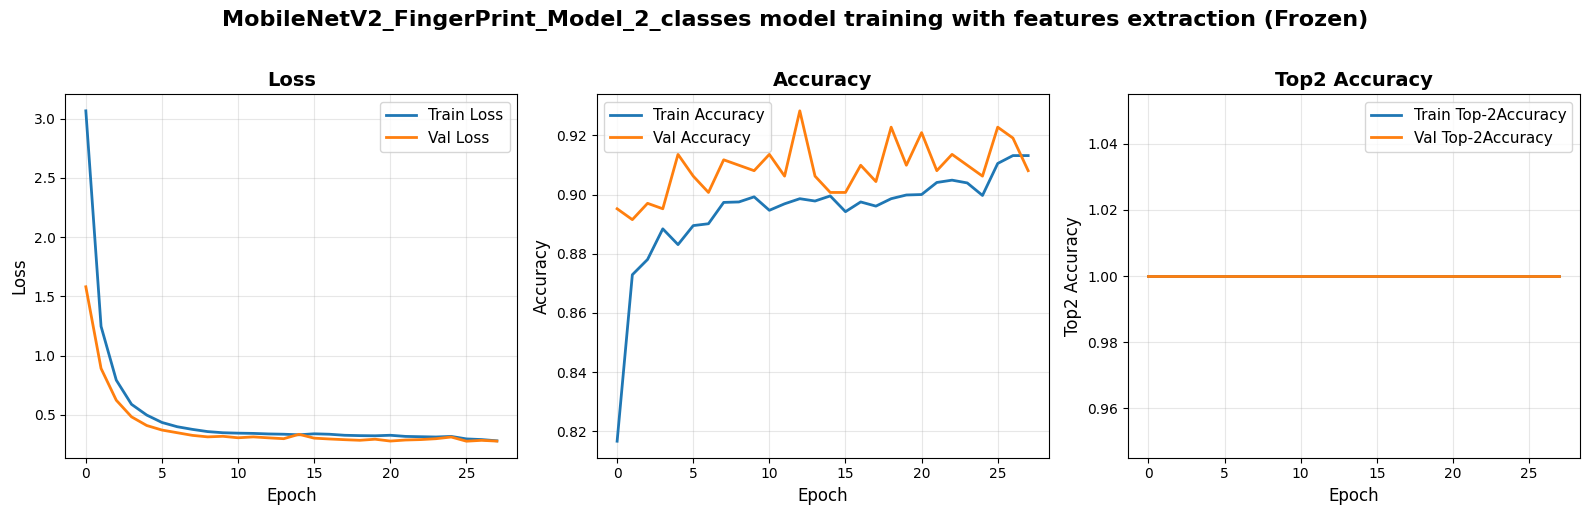

In [40]:
# display transfer learning history 
display_training_history(history_frozen, 'with features extraction (Frozen)')

## 6. Fine Tuning Training

In [41]:
# Constants
frozen_fingerprint_basemodel = base_model
frozen_fingerprint_model = mobilenet_fingerprint_model

# Number of layers in the model 
NUM_BASE_MODEL_LAYERS = len(frozen_fingerprint_basemodel.layers)

# keep ratio of 1/3 unfrozen layers vs. 2/3 frozen layers
UNFROZEN_FROZEN_LAYERS_RATIO = 0.33
NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS = int(NUM_BASE_MODEL_LAYERS * UNFROZEN_FROZEN_LAYERS_RATIO)

#  ratio of unfrozen first layers vs. unfrozen last layers
UNFROZEN_FROZEN_INPUT_OUTPUT_LAYERS_RATIO = 0
FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS = int(NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS * UNFROZEN_FROZEN_INPUT_OUTPUT_LAYERS_RATIO)
FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS = int(NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS - FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS)

# Low LR for fine tuning
FINE_TUNE_LR = 1e-5 

In [42]:
print("🔥 Fine-Tuning Preparation...\n")

# APPROCHE LA PLUS SIMPLE : Modifier le modèle frozen en place
print(f"💡 Strategy : unfreeze the {MobileNet_version} pre-trained base model and continue training\n")
print(f"Number of layers in the base model                      : {NUM_BASE_MODEL_LAYERS}")
print(f"Number of the first unfrozen layers in the base model   : {FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS}")
print(f"Number of the last unfrozen layers in the base model   : {FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS}")

# Unfreeze base model
frozen_fingerprint_basemodel.trainable = True

# Unfreeze the first FINE_TUNING_UNFREEZE_INPUT_BASE_MODEL_LAYERS-th layers
# Unfreeze the last FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS-th layers

for i, layer in enumerate(frozen_fingerprint_basemodel.layers):
    if i < FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS:
        layer.trainable = True
    elif i < (NUM_BASE_MODEL_LAYERS - FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS):
        layer.trainable = False
    else:
        layer.trainable = True


print(f"📊 Unfreeze configuration :")
print(f"  - Frozen layers   : {NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS}")
print(f"  - Unfrozen layers : {len(frozen_fingerprint_basemodel.layers) - NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS}")

# Model params counting 
trainable_count = sum([tf.size(w).numpy() for w in frozen_fingerprint_basemodel.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in frozen_fingerprint_basemodel.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Trainable params : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Frozen params    : {non_trainable_count:,}\n")

# Recompile model 
frozen_fingerprint_model.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

# Fine-tuned model with partial frozen base model 
finetuned_fingerprint_model = frozen_fingerprint_model

print(f"✅ Fingerprint model {finetuned_fingerprint_model.name} recompiled with low LR = {FINE_TUNE_LR}")

🔥 Fine-Tuning Preparation...

💡 Strategy : unfreeze the MobileNetV2 pre-trained base model and continue training

Number of layers in the base model                      : 155
Number of the first unfrozen layers in the base model   : 0
Number of the last unfrozen layers in the base model   : 51
📊 Unfreeze configuration :
  - Frozen layers   : 51
  - Unfrozen layers : 104
  - Trainable params : 1,855,104 (82.2%)
  - Frozen params    : 402,880

✅ Fingerprint model MobileNetV2_FingerPrint_Model_2_classes recompiled with low LR = 1e-05


In [43]:
# display base model unfrozen layers 
display_model_layers(frozen_fingerprint_basemodel, 10, FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS + 2)

🔍 Display MobileNetV2_FingerPrint_BaseModel model architecture


📌 First layers :
    1. input_layer                              | Output: (None, 96, 96, 3)              | Trainable: False
    2. Conv1                                    | Output: (None, 48, 48, 32)             | Trainable: False
    3. bn_Conv1                                 | Output: (None, 48, 48, 32)             | Trainable: False
    4. Conv1_relu                               | Output: (None, 48, 48, 32)             | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 48, 48, 32)             | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 48, 48, 32)             | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 48, 48, 32)             | Trainable: False
    8. expanded_conv_project                    | Output: (None, 48, 48, 16)             | Trainable: False
    9. expanded_conv_project_BN                 | Outp

In [44]:
# display model params 
finetuned_fingerprint_model.summary()

Model: "MobileNetV2_FingerPrint_Model_2_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,498 (9.93 MB)

 Trainable params: 2,199,618 (8.39 MB)

 Non-trainable params: 402,880 (1.54 MB)

### Fine Tuning Training

In [45]:
# Constants for training callbacks
EARLYSTOPPING_PATIENCE = 30
EARLYSTOPPING_VERBOSE = 1

REDUCELRONPLATEAU_FACTOR = 0.5
REDUCELRONPLATEAU_PATIENCE = 7
REDUCELRONPLATEAU_MIN_LR = 1e-8
REDUCELRONPLATEAU_VERBOSE = 1

fingerprint_model_name = MobileNet_version + "_FingerPrint_Model_" + str(num_classes) + "_classes_Fine_Tuning.keras"
MODELCHECKPOINT_PATH = fingerprint_model_dir + "/" + fingerprint_model_name
MODELCHECKPOINT_VERBOSE = 1

FIT_NUM_EPOCHS = 120
FIT_VERBOSE = 1

In [46]:
# Fine Tuning Training function
def fine_tuning_fingerprint_model(model: keras.Model, train_ds: tf.data.Dataset, val_ds: tf.data.Dataset):

    print("🚀 Fine-tuning FringerPrint Model...\n")

    # Callbacks 
    early_stopping_ft = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=EARLYSTOPPING_PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=EARLYSTOPPING_VERBOSE
    )

    reduce_lr_ft = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=REDUCELRONPLATEAU_FACTOR,
        patience=REDUCELRONPLATEAU_PATIENCE,
        min_lr=REDUCELRONPLATEAU_MIN_LR,
        verbose=REDUCELRONPLATEAU_VERBOSE
    )

    checkpoint_ft = callbacks.ModelCheckpoint(
        MODELCHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=MODELCHECKPOINT_VERBOSE
    )

    print(f"Training for {FIT_NUM_EPOCHS} epochs maximum...\n")

    history_finetuned = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FIT_NUM_EPOCHS,
        callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
        verbose=FIT_VERBOSE
    )

    print("\n✅ Fine-tuning complete !")
    print(f"   Number of epochs completed : {len(history_finetuned.history['loss'])}")

    # Best performances
    best_finetuned_val_acc = max(history_finetuned.history['val_accuracy'])
    best_finetuned_epoch = history_finetuned.history['val_accuracy'].index(best_finetuned_val_acc) + 1
    print(f"   Best validation accuracy : {best_finetuned_val_acc*100:.2f}% (epoch {best_finetuned_epoch})")

    if best_finetuned_val_acc < 0.70:
        print(f"\n⚠️  Warning : Accuracy of {best_finetuned_val_acc*100:.1f}% is below 70%")
    elif best_finetuned_val_acc < 0.80:
        print(f"\n✅ Good : Accuracy of {best_finetuned_val_acc*100:.1f}%")
    else:
        print(f"\n🎯 Excellent : Accuracy of {best_finetuned_val_acc*100:.1f}%")

    return history_finetuned, best_finetuned_val_acc

In [47]:
# fine tuning training
history_finetuned, best_finetuned_val_acc = fine_tuning_fingerprint_model(finetuned_fingerprint_model, 
                                                                          train_ds_prepared, 
                                                                          val_ds_prepared)

🚀 Fine-tuning FringerPrint Model...

Training for 120 epochs maximum...

Epoch 1/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.7012 - loss: 0.6931 - top2_accuracy: 1.0000
Epoch 1: val_accuracy improved from None to 0.90625, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models//MobileNetV2_FingerPrint_Model_2_classes_Fine_Tuning.keras

Epoch 1: finished saving model to /Users/laurent/Projects/projet-fingerprint-validator/models//MobileNetV2_FingerPrint_Model_2_classes_Fine_Tuning.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.7697 - loss: 0.5704 - top2_accuracy: 1.0000 - val_accuracy: 0.9062 - val_loss: 0.3173 - val_top2_accuracy: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8958 - loss: 0.3490 - top2_accuracy: 1.0000
Epoch 2: val_accuracy did not improve from 0.90625
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.8983 - loss: 0.3414 - top2_accuracy: 1.0000 - val_

In [48]:
# Basic Comparaison
improvement = (best_finetuned_val_acc - best_frozen_val_acc) * 100

print("\n📊 Comparison Transfer Learning vs. Fine Tuning (best validation accuracy only):")
print(f" - Transfer Learning    : {best_frozen_val_acc*100:.1f}%")
print(f" - Fine-tuned           : {best_finetuned_val_acc*100:.1f}%")
print(f" - Improvement          : {improvement:+.1f}%")


📊 Comparison Transfer Learning vs. Fine Tuning (best validation accuracy only):
 - Transfer Learning    : 92.8%
 - Fine-tuned           : 94.7%
 - Improvement          : +1.8%


In [49]:
# Make a few predictions using test dataset
make_prediction_samples(finetuned_fingerprint_model, test_ds_prepared)

🔍 Predictions samples of <Functional name=MobileNetV2_FingerPrint_Model_2_classes, built=True> model


📊 Prediction :
----------------------------------------------------------------------------------------------------
✅ Image 1: Label=thumb        | Prediction=thumb        | Confidence= 99.8% | 2nd Prediction=index        | 2nd Confidence=  0.3%
✅ Image 2: Label=thumb        | Prediction=thumb        | Confidence= 99.9% | 2nd Prediction=index        | 2nd Confidence=  0.1%
✅ Image 3: Label=index        | Prediction=index        | Confidence= 98.2% | 2nd Prediction=thumb        | 2nd Confidence=  1.7%
✅ Image 4: Label=thumb        | Prediction=thumb        | Confidence= 99.6% | 2nd Prediction=index        | 2nd Confidence=  0.4%
✅ Image 5: Label=thumb        | Prediction=thumb        | Confidence= 99.5% | 2nd Prediction=index        | 2nd Confidence=  0.6%
✅ Image 6: Label=index        | Prediction=index        | Confidence= 86.9% | 2nd Prediction=thumb        | 2nd Confidence= 13.0%
✅

2026-03-27 16:21:14.583858: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [50]:
# Evaluation using test dataset
print("📊 Evaluation of fine tuned model using test dataset...\n")

results_test_model_fine_tuning= finetuned_fingerprint_model.evaluate(test_ds_prepared, verbose=0)
fine_tuning_test_accuracy = results_test_model_fine_tuning[1]
fine_tuning_test_top2_accuracy = results_test_model_fine_tuning[2]

print("Results :")
print(f"  - Loss                : {results_test_model_fine_tuning[0]:.4f}")
print(f"  - Accuracy            : {fine_tuning_test_accuracy*100:.2f}%")
print(f"  - Top-2 Accuracy      : {fine_tuning_test_top2_accuracy*100:.2f}%")

# check overfitting
# Evaluation using validation data
results_val_fine_tuning = finetuned_fingerprint_model.evaluate(val_ds_prepared, verbose=0)
fine_tuning_val_accuracy = results_val_fine_tuning[1]

print(f"\nCheck overfitting :")
print(f"  - Validation Accuracy : {fine_tuning_val_accuracy*100:.2f}%")
print(f"  - Test Accuracy       : {fine_tuning_test_accuracy*100:.2f}%")

📊 Evaluation of fine tuned model using test dataset...

Results :
  - Loss                : 0.3452
  - Accuracy            : 92.97%
  - Top-2 Accuracy      : 100.00%

Check overfitting :
  - Validation Accuracy : 94.67%
  - Test Accuracy       : 92.97%


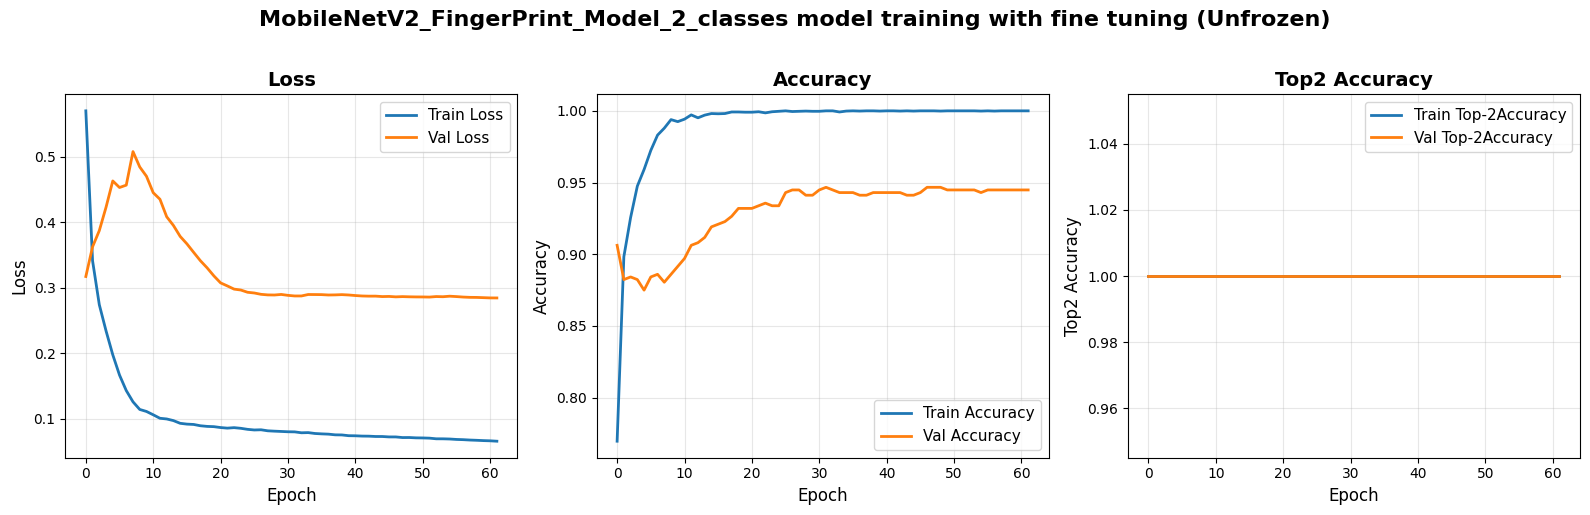

In [51]:
# display fine tuning history 
display_training_history(history_finetuned, 'with fine tuning (Unfrozen)')

## 7. Compare Transfer Learning and Fine Tuning Training Results

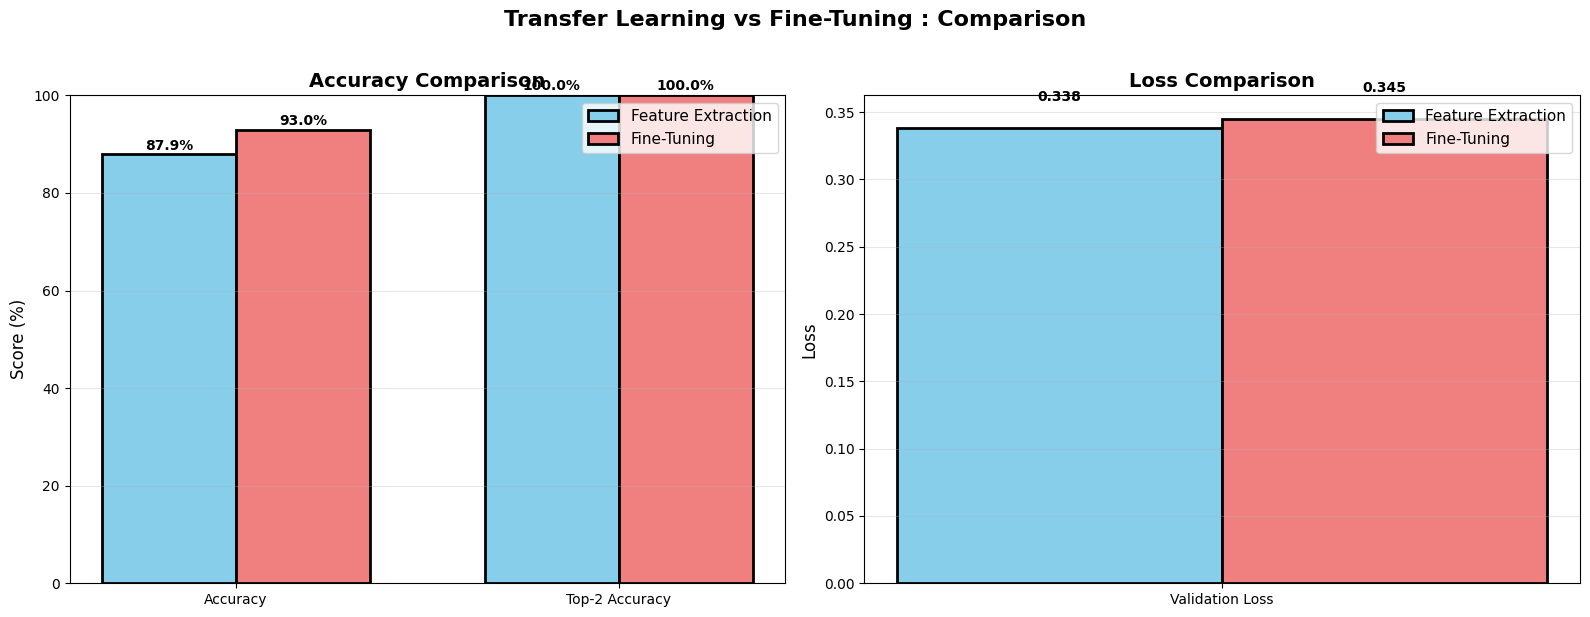

In [52]:
# Graph for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracies comparison
metrics = ['Accuracy', 'Top-2 Accuracy']
frozen_scores = [results_test_model_frozen[1]*100, results_test_model_frozen[2]*100]
finetuned_scores = [results_test_model_fine_tuning[1]*100, results_test_model_fine_tuning[2]*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, frozen_scores, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[0].bar(x + width/2, finetuned_scores, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 100])

# Ajouter les valeurs sur les barres
for i, (f, ft) in enumerate(zip(frozen_scores, finetuned_scores)):
    axes[0].text(i - width/2, f + 1, f'{f:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, ft + 1, f'{ft:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Comparaison des loss
categories = ['Validation Loss']
frozen_loss = [results_test_model_frozen[0]]
finetuned_loss = [results_test_model_fine_tuning[0]]

x2 = np.arange(len(categories))
axes[1].bar(x2 - width/2, frozen_loss, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[1].bar(x2 + width/2, finetuned_loss, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Ajouter les valeurs
axes[1].text(x2[0] - width/2, frozen_loss[0] + 0.02, f'{frozen_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].text(x2[0] + width/2, finetuned_loss[0] + 0.02, f'{finetuned_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Transfer Learning vs Fine-Tuning : Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Confusion Matrix

📊 Confusion Matrix and Detailed Analysis...



2026-03-27 16:21:18.078007: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


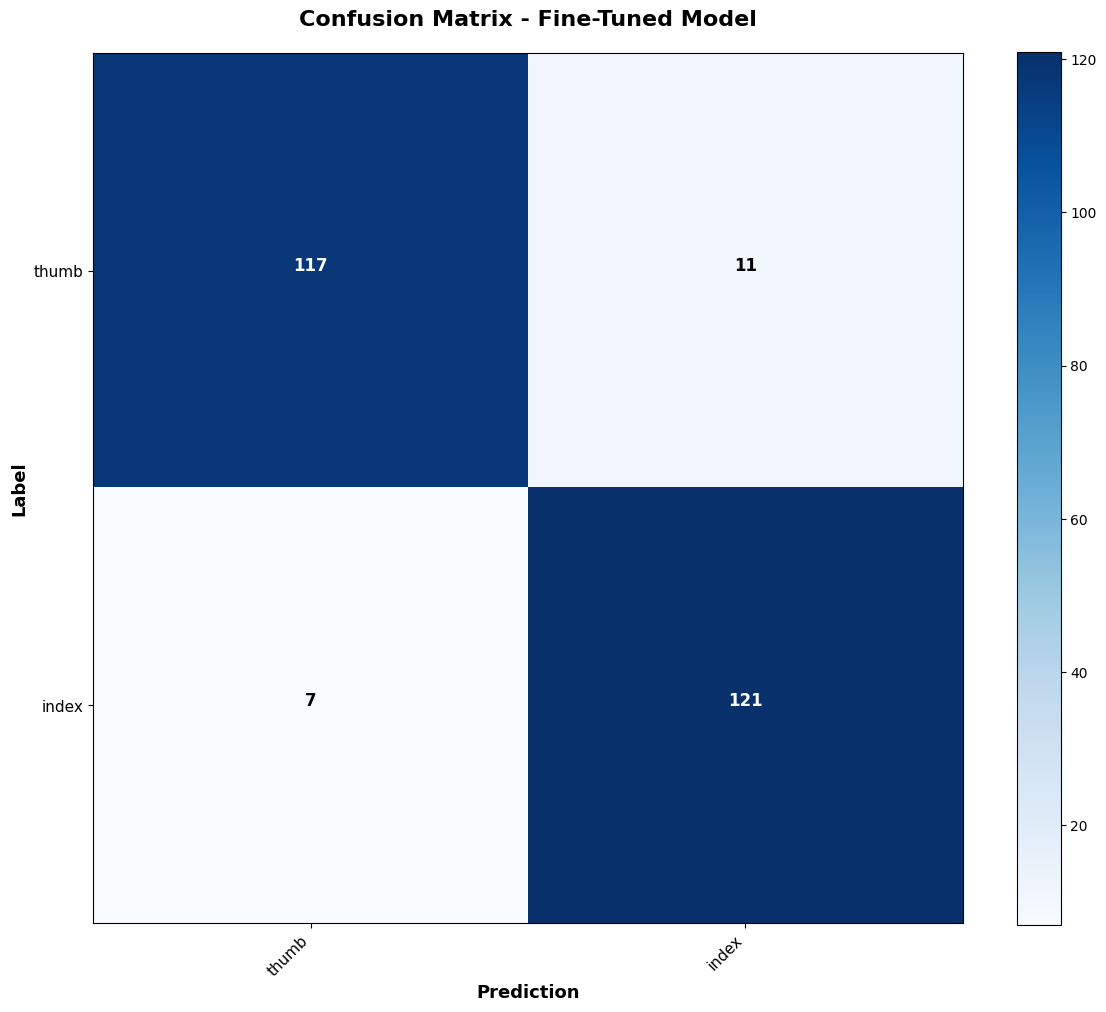


📄 Detailed classification report :

              precision    recall  f1-score   support

       thumb      0.944     0.914     0.929       128
       index      0.917     0.945     0.931       128

    accuracy                          0.930       256
   macro avg      0.930     0.930     0.930       256
weighted avg      0.930     0.930     0.930       256



In [53]:
print("📊 Confusion Matrix and Detailed Analysis...\n")

# Get the predictions
y_true = []
y_pred = []

for images, labels in test_ds_prepared:
    predictions = finetuned_fingerprint_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Fine-Tuned Model', fontsize=16, fontweight='bold', pad=20)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(tick_marks, class_names, fontsize=11)

# Add values in cells
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=12, fontweight='bold')

plt.ylabel('Label', fontsize=13, fontweight='bold')
plt.xlabel('Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Dump classification report
print("\n📄 Detailed classification report :\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

### Detailed Analysis by Class

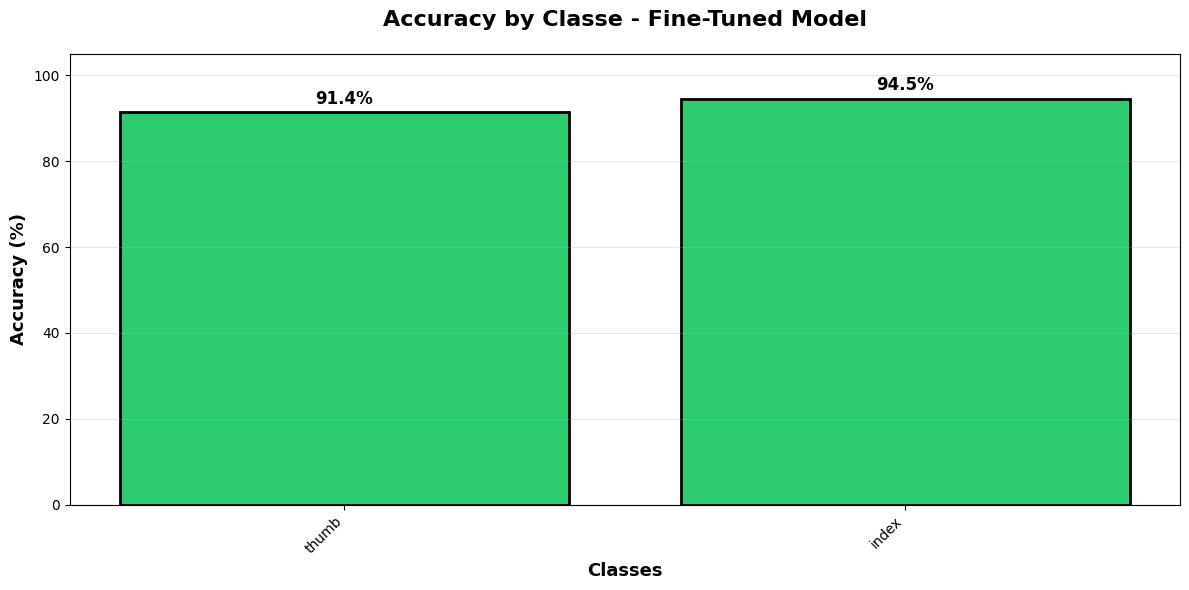


🏆 Best class : index (94.5%)
⚠️  Worst class : thumb (91.4%)


In [54]:
# Compute accuracy by class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if acc > 0.85 else '#f39c12' if acc > 0.75 else '#e74c3c' for acc in class_accuracies]
bars = ax.bar(class_names, class_accuracies * 100, color=colors, edgecolor='black', linewidth=2)

# Add bar values
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Classes', fontsize=13, fontweight='bold')
ax.set_title('Accuracy by Classe - Fine-Tuned Model', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim([0, 105])
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identify best and worst classes
best_class_idx = np.argmax(class_accuracies)
worst_class_idx = np.argmin(class_accuracies)

print(f"\n🏆 Best class : {class_names[best_class_idx]} ({class_accuracies[best_class_idx]*100:.1f}%)")
print(f"⚠️  Worst class : {class_names[worst_class_idx]} ({class_accuracies[worst_class_idx]*100:.1f}%)")

## 8. Prepare FingerPrint model for production

In [55]:
# prediction function
def predict_fingerprint(model, image_input_size, fingerprint_image_path, class_names, topk_predictions):
    """
    Predict the fingerprint class given an image with fine)tuned model
    
    Args:
        model: fingerprint trained model
        image_input_size: size of images expected for the trained model
        fingerprint_image_path: fingerprint image path
        class_names: classes names
        topk_predictions: integer for reporting top-k predictions
    """

    try:
        # Load and prep image for prediction
        img = tf.keras.preprocessing.image.load_img(fingerprint_image_path, target_size=image_input_size)

        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
        img_array = preprocess_input(img_array)  # Normalisation with MobileNet
    except Exception as e:
        print(f"")
        return(0)
    
    # Prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Report top-k prédictions
    topk_idx = np.argsort(predictions[0])[-topk_predictions:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],        
        'top-k': [(class_names[i], predictions[0][i]) for i in topk_idx]
    }

print("✅ Prediction function created !")

✅ Prediction function created !


🔮 Predictions using randomly selected images...



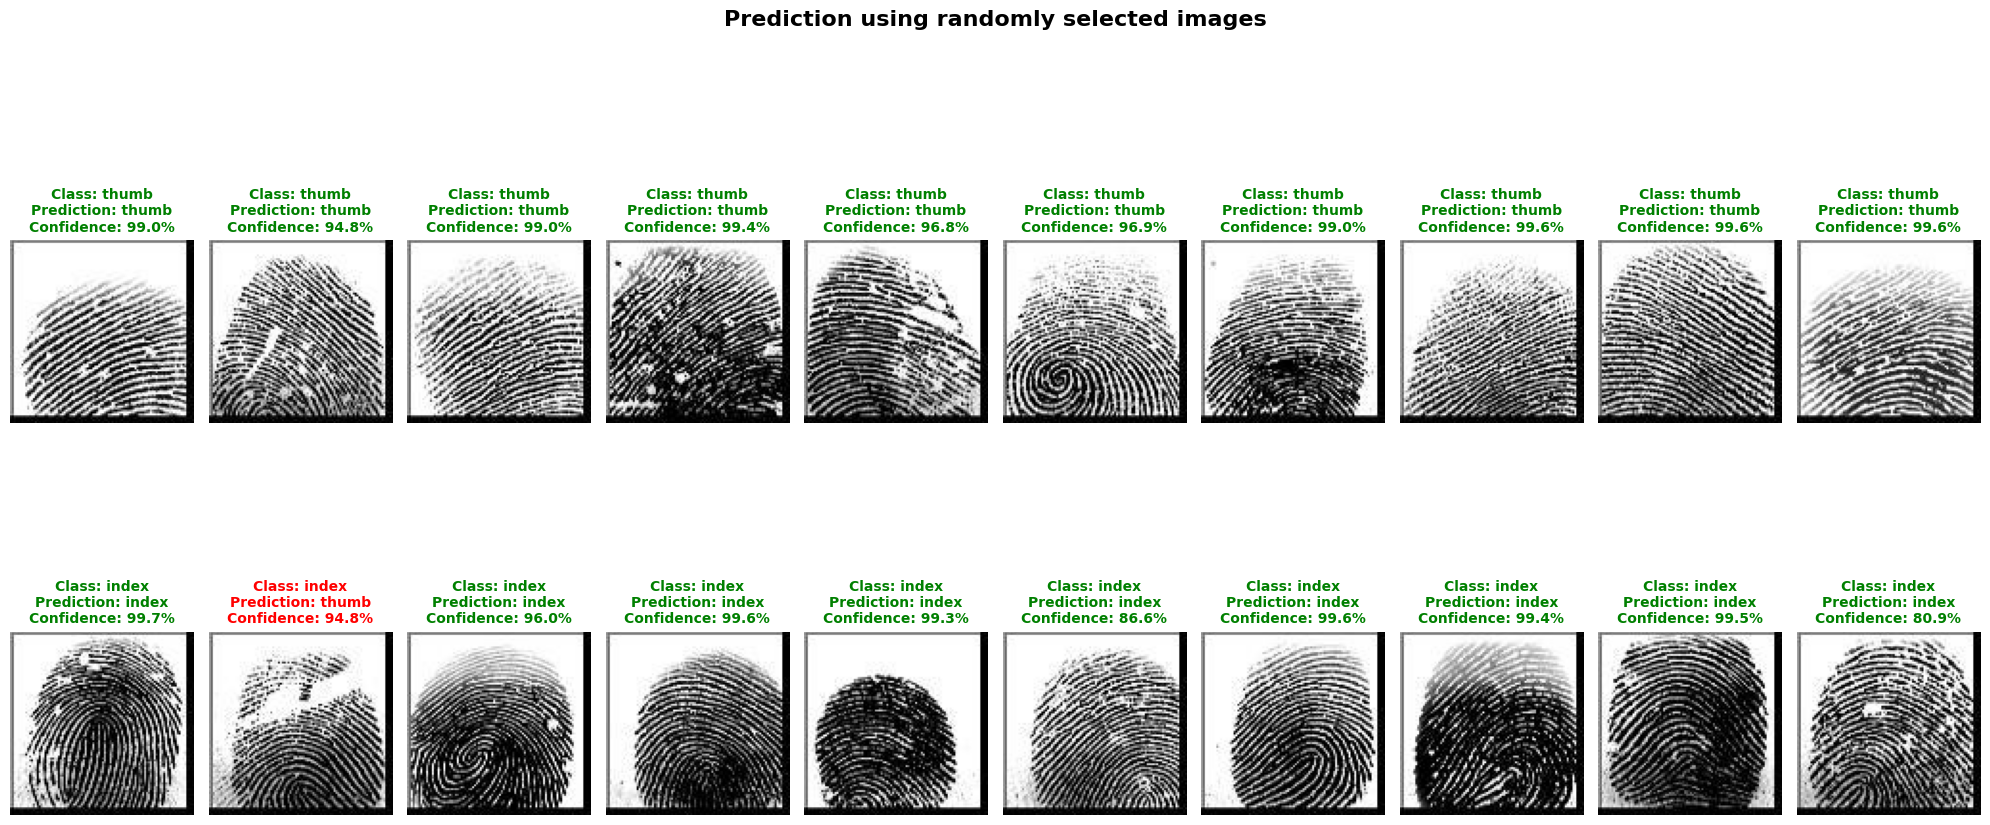

In [56]:
print("🔮 Predictions using randomly selected images...\n")

num_examples_prediction = 10

# Select randomly a few images
test_images_predictions = []

for class_name in class_names:
    class_path = Path(os.path.join(DATASET_ROOTDIR_PATH + "/validation", class_name))
    images = list(class_path.glob('*.*'))

    # Randomly select num_examples images in each class
    test_images_predictions.extend(random.sample(images, min(num_examples_prediction, len(images))))

fig, axes = plt.subplots(len(class_names), num_examples_prediction, figsize=(20, 10))
axes = axes.flatten()

for idx, img_path in enumerate(test_images_predictions[:num_examples_prediction * len(class_names)]):
    # Predict
    result = predict_fingerprint(finetuned_fingerprint_model, IMAGE_SIZE, img_path, class_names, 2)
    
    # Display image
    img = plt.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Vraie classe (depuis le nom du dossier)
    filename = os.path.basename(img_path)
    if filename.find("thumb") != -1:
        true_class = "thumb"
    elif filename.find("index") != -1:
        true_class = "index"
    elif filename.find("middle") != -1:
        true_class = "middle"
    elif filename.find("ring") != -1:
        true_class = "ring"
    elif filename.find("little") != -1:
        true_class = "little"
    else:
        true_class = None
    
    predicted_class = result['predicted_class']
    confidence = result['confidence']
    
    # Color-code result : green-correct vs. red-incorrect 
    color = 'green' if true_class == predicted_class else 'red'
    
    # Title
    title = f"Class: {true_class}\nPrediction: {predicted_class}\nConfidence: {confidence*100:.1f}%"
    axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

plt.suptitle('Prediction using randomly selected images', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### VIsualize all probabilities for a few selected images

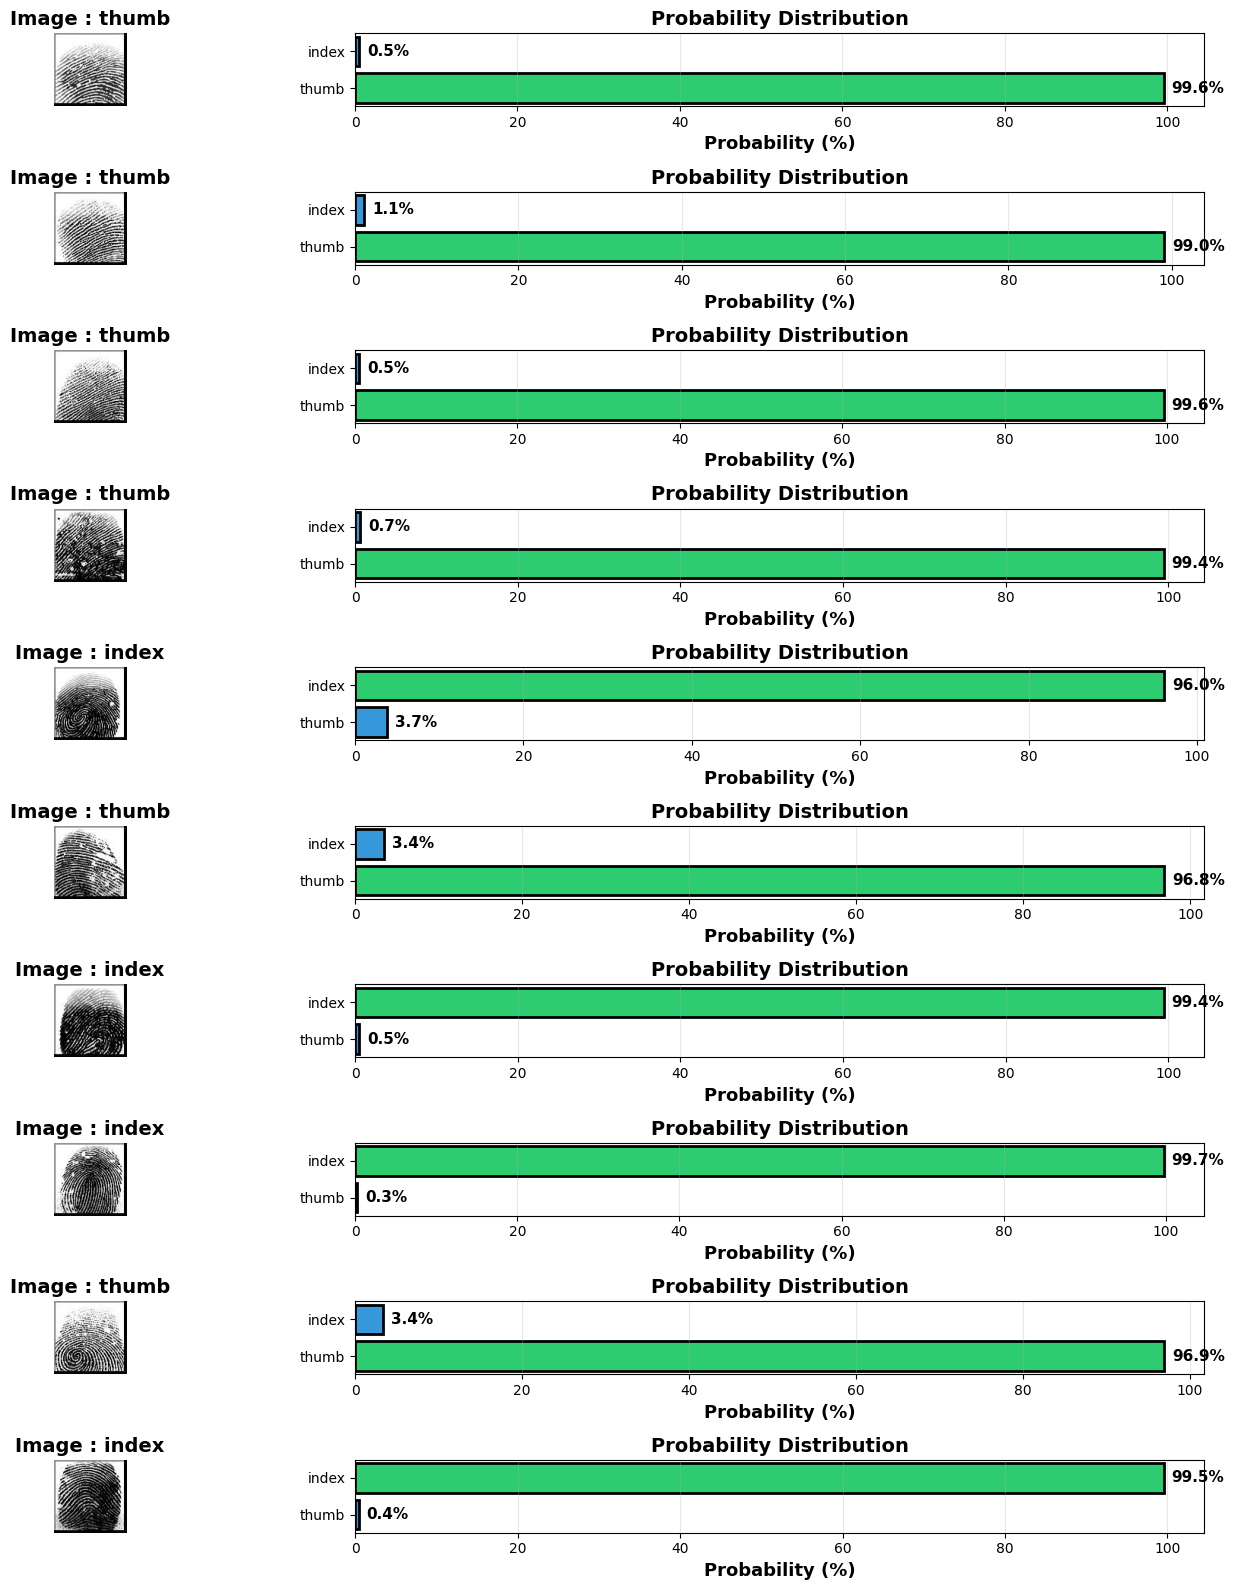

In [57]:
# Select few images from the above set
num_examples_probabilities = 10

# Randomly select num_examples images in each class
test_images_probabilities = random.sample(test_images_predictions, num_examples_probabilities)

fig, axes = plt.subplots(num_examples_probabilities, 2, figsize=(16, 16))

for idx, img_path in enumerate(test_images_probabilities[:num_examples_probabilities]):

    sample_image_path = test_images_probabilities[idx]
    result = predict_fingerprint(finetuned_fingerprint_model, IMAGE_SIZE, sample_image_path, class_names, 2)

    # Image
    img = plt.imread(sample_image_path)
    axes[idx, 0].imshow(img)
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title(f"Image : {sample_image_path.parent.name}", fontsize=14, fontweight='bold')

    # Probabilities
    probs = result['all_probabilities'] * 100
    colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

    bars = axes[idx, 1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
    axes[idx, 1].set_xlabel('Probability (%)', fontsize=13, fontweight='bold')
    axes[idx, 1].set_title('Probability Distribution', fontsize=14, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3, axis='x')

    # Add values
    for bar, prob in zip(bars, probs):
        width = bar.get_width()
        axes[idx, 1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                    f'{prob:.1f}%',
                    ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()